# Initial Inspection of the VLA-ANGST H I Spectral Cube for NGC 3741
---
## 1.1 Aim

This notebook presents an initial qualitative inspection of the naturally weighted VLA-ANGST H I spectral cube for **NGC 3741**, a nearby dwarf irregular galaxy at an adopted distance of $3.0 \pm 0.3\ \mathrm{Mpc}$ (Gentile et al., 2007). 

<p align="center">
![NGC 3741 imaged by the HST](ngc3741.png)  
</p>
<p style="text-align: center;"> 
    Optical image of NGC 3741 from Hubble Space Telescope observations.
</p>

## 1.2 Scientific background

NGC 3741 has a faint stellar component surrounded by an exceptionally extended disk of neutral atomic hydrogen. Using Westerbork Synthesis Radio Telescope observations and three-dimensional kinematic modeling, Gentile et al. (2007) traced its rotation curve to a radius of approximately $6.6\ \mathrm{kpc}$, about 42 B-band exponential scale lengths and approximately $15R_{25}$. The authors also reported a strong, approximately symmetric warp and non-circular motions of roughly $5$–$13\ \mathrm{km\,s^{-1}}$.

NGC 3741 is fascinating object for three-dimensional visualization because its H I gas disk extends much beyond its visible starlight.  

<h3 style="text-align: center;">Selected Properties</h3>

| Property | Reported value |
|---|---:|
| Galaxy type | Dwarf irregular |
| Adopted distance | $3.0 \pm 0.3\ \mathrm{Mpc}$ |
| Absolute B-band magnitude | $M_B=-13.13$ |
| B-band luminosity | $2.7\times10^7\,L_\odot$ |
| Systemic H I velocity | $228\ \mathrm{km\,s^{-1}}$ |
| Optical radius, $R_{25}$ | $30.7''$ |
| Maximum traced H I radius | Approximately $6.6\ \mathrm{kpc}$ |
| Relative H I extent | 42 B-band scale lengths; approximately $15R_{25}$ |
| Integrated H I flux | $59.6\ \mathrm{Jy\,km\,s^{-1}}$ |
| H I mass | $1.3\times10^8\,M_\odot$ |
| Total gas mass, including helium | $1.7\times10^8\,M_\odot$ |
| Characteristic H I velocity dispersion | Approximately $6\ \mathrm{km\,s^{-1}}$ |
| Reported non-circular motions | Approximately $5$–$13\ \mathrm{km\,s^{-1}}$ |
| H I morphology | Strong, approximately symmetric warp |

<p style="text-align: center;"> Values reported by Gentile et al. (2007) from WSRT observations and associated modeling. </p>

## 1.3 Data source and cube structure

The data were obtained from the [VLA-ANGST survey](https://science.nrao.edu/science/surveys/vla-angst), an NRAO Large Program that observed the 21 cm line of H I in 35 nearby galaxies within approximately $4\ \mathrm{Mpc}$ (Ott et al., 2012). This project uses the naturally weighted NGC 3741 data cube. Natural weighting favors sensitivity to faint, extended emission, which is useful for examining NGC 3741's diffuse H I disk, although it provides lower spatial resolution than robust weighting.

The cube is a position–position–velocity (PPV) data product. Its axes correspond to line-of-sight velocity, Declination pixel and Right Ascension pixel, and each voxel records H I flux density in $\mathrm{Jy\,beam^{-1}}$. The velocity axis describes motion along the observer's line of sight rather than physical depth. The released cube is not corrected for primary-beam attenuation and its velocities are expressed relative to the Local Standard of Rest (Ott et al., 2012; NRAO, n.d.).

### Properties of NGC 3741 Natural-Weighted VLA-ANGST Data Cube 
| $B_{major}$ (") | $B_{minor}$ (") | BPA (°) | Noise ($mJy\;beam^{-1}$) | Channel Width ($km\;s^{-1}$) | $N_{pixels}$ | Pixel Scale (") |
|---|---|---|---|---|---|---|
|7.6|6.2|81.1|1.0|1.3|$1024^2$|1.5|  

<p style="text-align: center;"> Values reported by Ott et al. (2012) from the VLA-ANGST survey and associated data products. </p>

<div class="alert alert-info"> When the file is opened, `spectral_cube` may report that it has selected the Stokes I component. Stokes I represents total intensity and is the appropriate component for this analysis. </div>

In [1]:
from pathlib import Path
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from spectral_cube import SpectralCube

cubePath = Path("VLA-ANGST_HI_NGC3741-nat-cube.fits.gz")
cube = SpectralCube.read(cubePath)

velocities = cube.spectral_axis.to_value(u.km / u.s)
channelWidth = np.nanmedian(np.abs(np.diff(velocities)))

print("Cube:", cubePath.name)
print("Shape (velocity, Dec. pixel, R.A. pixel):", cube.shape)
print("Flux-density unit:", cube.unit)
print(f"Velocity range of cube: {velocities.min():.1f} to {velocities.max():.1f} km/s")
print(f"Approximate spacing per channel: {channelWidth:.2f} km/s")

Cube: VLA-ANGST_HI_NGC3741-nat-cube.fits.gz
Shape (velocity, Dec. pixel, R.A. pixel): (115, 1024, 1024)
Flux-density unit: Jy / beam
Velocity range of cube: 154.2 to 301.3 km/s
Approximate spacing per channel: 1.29 km/s


The spectral coordinates are converted to velocities ($km\,s^{-1}$) for consistency.

The cube shape is $(115,1024,1024)$, corresponding to 115 velocity channels and a $1024\times1024$ spatial image in each channel. It therefore contains 120,586,240 voxels before any signal masking or spatial reduction.

## 1.4 Inspection of middle velocity channel

As an initial view, the middle channel of the cube was selected using integer division. A single channel map shows the spatial distribution of H I flux density within one narrow interval of line-of-sight velocity.

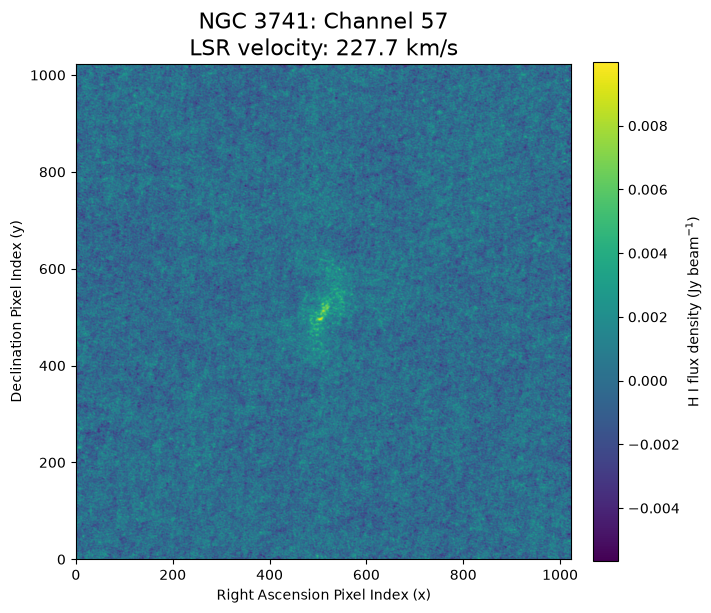

In [2]:
channel_number = cube.shape[0] // 2
channel = cube[channel_number]
channel_velocity = velocities[channel_number]

plt.figure(figsize=(7, 7))
plt.imshow(channel.value, origin="lower", cmap="viridis")
plt.colorbar(label=r"H I flux density (Jy beam$^{-1}$)", fraction=0.046, pad=0.04)

plt.title(f"NGC 3741: Channel {channel_number}\n"
        f"LSR velocity: {channel_velocity:.1f} km/s", fontsize=16, fontweight='400')
plt.xlabel("Right Ascension Pixel Index (x)")
plt.ylabel("Declination Pixel Index (y)")
plt.show()

### 1.4.1 Observations

Channel 57 corresponds to an LSR velocity of approximately $227.7\ \mathrm{km\,s^{-1}}$, close to the published systemic velocity of $228\ \mathrm{km\,s^{-1}}$ (Gentile et al., 2007). 

A localized, elongated region of comparatively high flux density is visible near the central pixels, while most of the surrounding field exhibits weaker grain-like fluctuations consistent with background noise.

The channel shows detectable emission the systemic velocity. The surrounding image also indicates why noise must be characterized and masked before the cube is converted into a three-dimensional point representation.

## 1.5 H I emission across sampled velocity channels

To examine how the apparent location and morphology of the emission change with velocity, 12 approximately evenly spaced channels were selected from channels 10 through 104. The sampling excludes the most extreme ten channels at each end of the cube as these channels are less likely to contain qualitatively significant H I emission. Each panel is a two-dimensional spatial map at a different velocity channel.

The panels are scaled independently using the 5th and 99.8th percentiles of their pixel values. This choice was made to limit the visual influence of extreme pixels, making faint structure easier to see. 

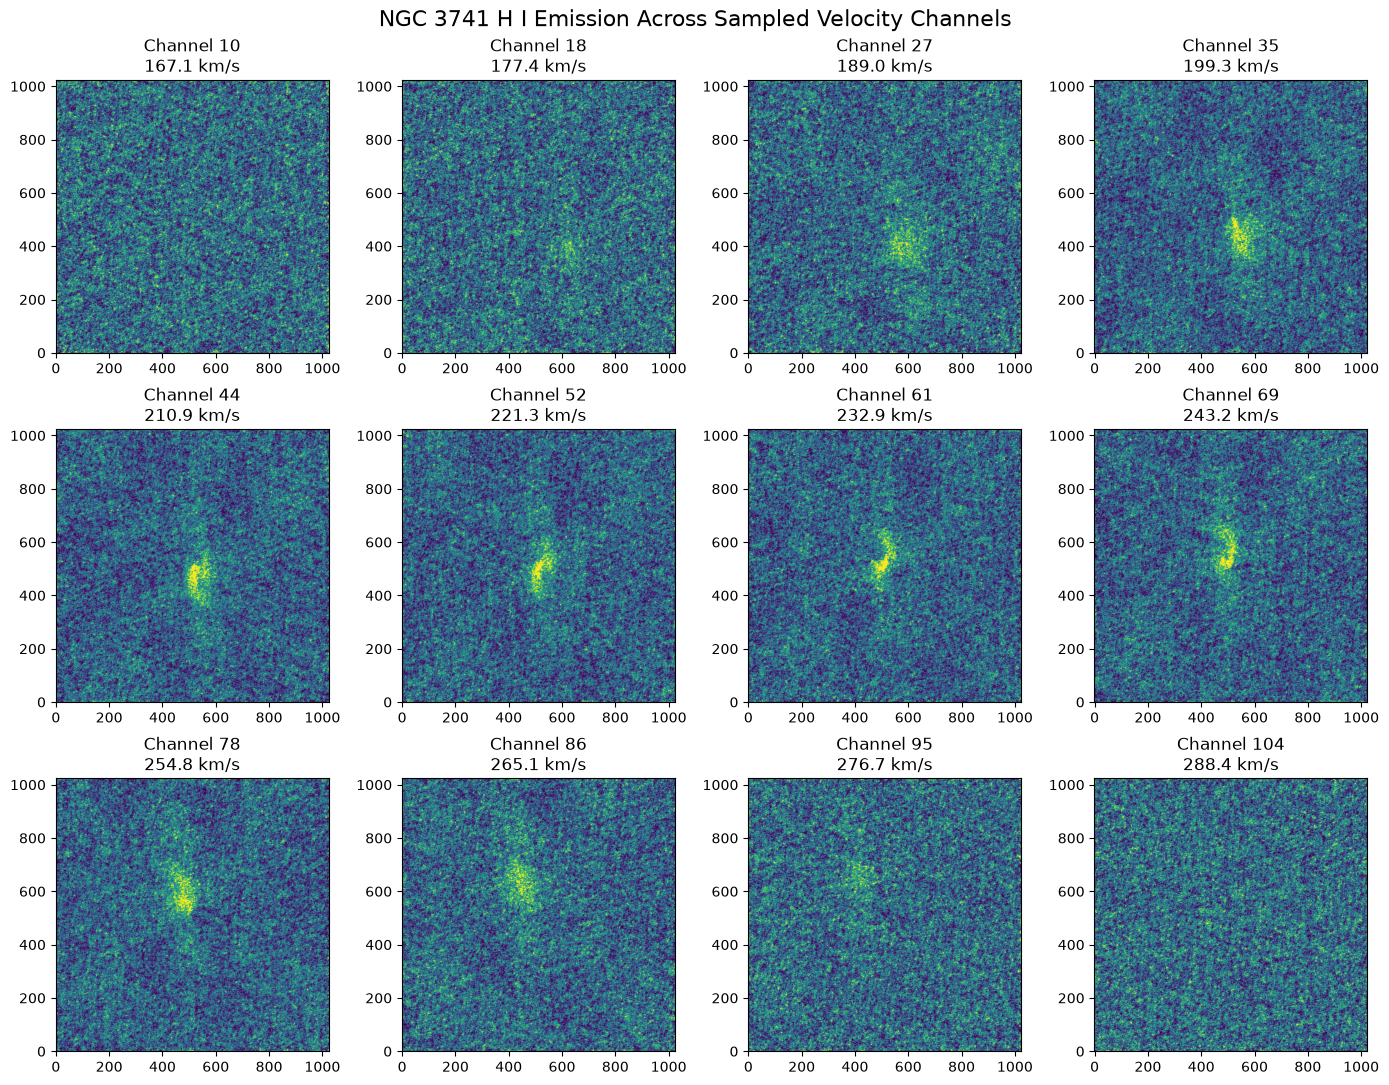

In [3]:
channel_numbers = np.linspace(10, cube.shape[0] - 11, 12, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))

for ax, channel_number in zip(axes.flat, channel_numbers):
    image = cube[channel_number].value

    lower = np.nanpercentile(image, 5)
    upper = np.nanpercentile(image, 99.8)

    ax.imshow(image, origin="lower", cmap="viridis", vmin=lower, vmax=upper)
    
    ax.set_title(
        f"Channel {channel_number}\n"
        f"{velocities[channel_number]:.1f} km/s")

fig.suptitle(
    "NGC 3741 H I Emission Across Sampled Velocity Channels",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 1.5.1 Observations and interpretation

H I emission is visually apparent in the sampled maps from approximately $189$ to $265\ \mathrm{km\,s^{-1}}$; the maps at the lowest and highest sampled velocities are dominated by noise.

Within the displayed sequence, the location of the emission changes systematically in image-pixel coordinates. At velocities below the systemic velocity, the emission is displaced toward the lower-right portion of the panels. At higher velocities, it passes through the central region and becomes displaced toward the upper-left. Such pattern appears consistent with the rotation of an inclined gas disk, although I do not model the rotation quantitatively here.

### 1.5.2 Limitations

- The cube has not yet been masked by signal-to-noise ratio, so faint apparent structures may be noise.
- Each panel has an independent color scale; relative brightness cannot be compared across channels.
- Only 12 of the 115 channels are displayed, so the apparent emission limits are approximate.
- The panels use image pixels rather than a fully annotated celestial-coordinate projection.
- A velocity-dependent positional shift is consistent with rotation, but quantitative kinematic parameters require additional modeling.

## 1.6 Conclusions

The initial inspection identifies localized H I emission across multiple velocity channels and a systematic change in its spatial position with velocity.

The large number of noise-dominated voxels makes direct export of the complete cube computationally inefficient and busy. The next stage of the project will therefore estimate the noise, construct a three-dimensional signal mask, and export only probable H I emission for Blender. The resulting Blender coordinates will represent R.A., Declination and line-of-sight velocity, not the galaxy in physical three-dimensional space - an important distinction.